# To do
- ~~Analyze lick data~~
    - ~~RT~~
    - ~~Lick rate~~
    - ~~ILI~~
- History kernels
- Add HMM

In [1]:
# Standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel

# Own
from glue_sessions.glue_sessions import *
from intersession import glue_animals_intersessions
from my_fun import *
from licks.licks import *
from psychometric_curves import *
from kernels.psychophysical_kernels import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2
%matplotlib inline
# %config InlineBackend.figure_format = 'svg'  # Default is 'png'
# %config InlineBackend.figure_format = 'retina'

In [3]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
default_figsize = np.array(plt.rcParams['figure.figsize'])

# Analyses of drug data from batch #6

# Load behavioral data

In [4]:
# Set parameters
experiment = '2AFC_6'  # Set the experiment (batch)
animals = ['014', '016', '017', '020', '021', '022', '023', '024', '025']

# Load trial data (lick analyses)
df_behavior = glue_animals(experiment=experiment, filter_drug=True, update=False, to_csv=False)

# Load intersession data
df_intersessions = glue_animals_intersessions(experiment=experiment, filter_drug=True, update=False, to_csv=False)

# Filter data

In [5]:
df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Something is off in the parsing of the subjects in this group (probably because their IDs start with 0) and their IDs are missing the 0 padding. Add it so everything works
df_behavior.Subject = df_behavior.Subject.astype(str)
df_behavior['Subject'] = df_behavior['Subject'].str.zfill(3)
df_intersessions.Subject = df_intersessions.Subject.astype(str)
df_intersessions['Subject'] = df_intersessions['Subject'].str.zfill(3)

# Remove animals not in 'animals'
df_behavior = df_behavior[df_behavior.Subject.isin(animals)].reset_index(drop=True)
df_intersessions = df_intersessions[df_intersessions.Subject.isin(animals)].reset_index(drop=True)
assert df_behavior.Subject.unique().tolist() == animals

In [6]:
# Remove bad sessions

# Add paired session index
n_paired_sessions = len(df_intersessions) // 2
print(f'{n_paired_sessions:.0f} paired sessions')
paired_sessions = np.repeat(np.arange(n_paired_sessions), 2)
df_intersessions['PairedSession'] = paired_sessions

# Remove from intersession data
threshold = 0.5
bad_sessions = df_intersessions[df_intersessions.Accuracy < threshold].PairedSession
print(f'Bad sessions: {bad_sessions}')
df_intersessions = df_intersessions[~df_intersessions.PairedSession.isin(bad_sessions)].reset_index(drop=True)
print(f'Dropped {(len(bad_sessions) / n_paired_sessions)*100}% paired sessions')

# Remove from trial data


68 paired sessions
Bad sessions: 103    51
105    52
Name: PairedSession, dtype: int32
Dropped 2.941176470588235% paired sessions


# Behavioral metrics

## Standard

In [7]:
# Define function to compare behavioral metrics between saline and drug conditions
def plot_var_drug(df_intersessions, var_name='Accuracy', color='k'):
    """
    Plot a variable (e.g., accuracy) for each subject and drug condition together with the mean and sem across subjects, and run a t-test between saline and drug conditions.
    :param df_intersessions: DataFrame containing intersession data from all animals
    :param var_name: Name of the variable to plot (e.g., 'Accuracy')
    :return: None
    """

    var = df_intersessions.groupby(['Subject', 'Drug'])[var_name].mean().reset_index()
    var_mean = var.groupby('Drug')[var_name].mean()
    var_sem = var.groupby('Drug')[var_name].sem()

    # Plot paired lines
    # plt.figure(constrained_layout=True)
    plt.figure(figsize=default_figsize/2, constrained_layout=True)
    sns.lineplot(data=var, x='Drug', y=var_name, hue='Subject', marker='o', palette=['gray'] * var.Subject.nunique(), alpha=0.25, legend=False)
    # Plot mean and SEM
    plt.errorbar(x=var_mean.index, y=var_mean.values, yerr=var_sem.values, fmt='-o', color=color)
    # plt.title(var_name)
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    # plt.ylim([0.5, 1])
    plt.ylabel(var_name)
    # plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))  # Set a global formatter for y-axis ticks for equal sized plots
    sns.despine()

    # Run t-test
    saline = var[var['Drug'] == 0][var_name]
    drug = var[var['Drug'] == 1][var_name]
    t_stat, p_val = ttest_rel(saline, drug)
    print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
    add_star_between(p_val)

Accuracy: t-statistic = 8.632, p-value = 0.000
AccMaxEvi: t-statistic = 9.174, p-value = 0.000
LateralBias: t-statistic = -0.862, p-value = 0.414
AbsLatBias: t-statistic = -5.564, p-value = 0.001
MissRate: t-statistic = 1.016, p-value = 0.340
CorrRepBias: t-statistic = -5.384, p-value = 0.001


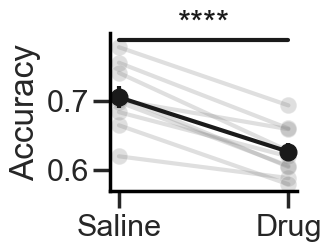

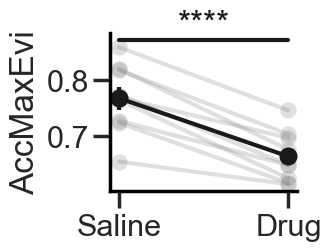

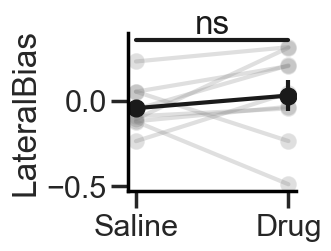

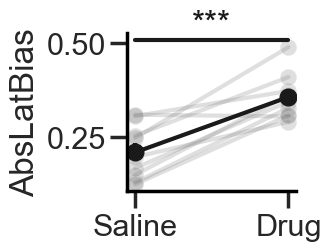

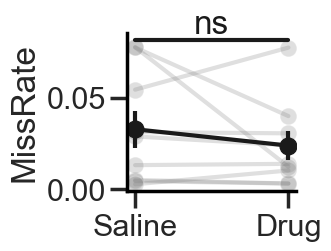

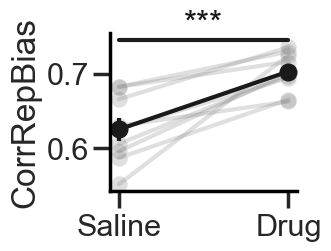

In [8]:
df_intersessions['AbsLatBias'] = abs(df_intersessions.LateralBias)  # Add new column

plot_var_drug(df_intersessions, var_name='Accuracy')
plot_var_drug(df_intersessions, var_name='AccMaxEvi')
plot_var_drug(df_intersessions, var_name='LateralBias')
plot_var_drug(df_intersessions, var_name='AbsLatBias')
plot_var_drug(df_intersessions, var_name='MissRate')
plot_var_drug(df_intersessions, var_name='CorrRepBias')

## Licks

### Add lick data

In [9]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Add session half index (0 for the 1st and 1 for the 2nd)
df_behavior['SessionHalf'] = (df_behavior.Trial >= df_behavior.groupby('Session').Trial.transform('max') / 2).astype(int)
# Add absolute ILD
loc = df_behavior.columns.get_loc('ILD') + 1
df_behavior.insert(loc, 'absILD', df_behavior['ILD'].abs())

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

# df_behavior.head()

1.11% of premature lick trials (before response window)
Port1In or Port2In are already lists
['absILD', 'LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'nLicks', 'leftILI', 'rightILI', 'ILI', 'RT', 'RT2', 'SessionHalf']


### RTs

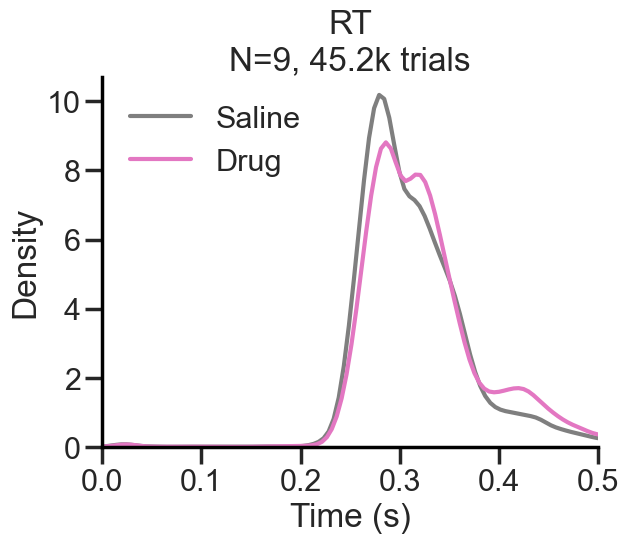

In [10]:
plot_licks_split(df_behavior, var='RT', split='drug', kind='kde')

In [11]:
# plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='RT', split='drug', kind='kde')

RT: t-statistic = -1.872, p-value = 0.098


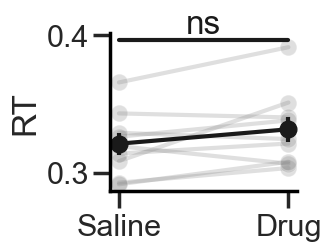

In [12]:
# Stats
plot_var_drug(df_behavior, var_name='RT')
# plot_var_drug(df_behavior[df_behavior.Hit==0], var_name='RT', color='tab:red')
# plot_var_drug(df_behavior[df_behavior.Hit==1], var_name='RT', color='tab:green')

Text(0.5, 1.0, 'Saline')

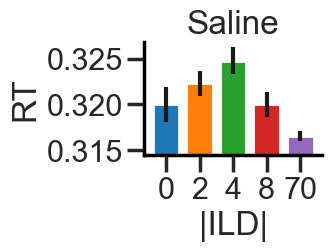

In [13]:
# Saline
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='RT')
plt.title('Saline')

Text(0.5, 1.0, 'Drug')

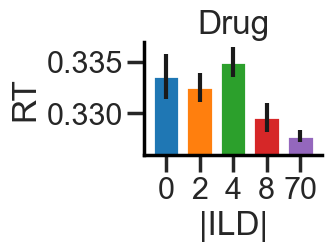

In [14]:
# Drug
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='RT')
plt.title('Drug')

### Lick rate

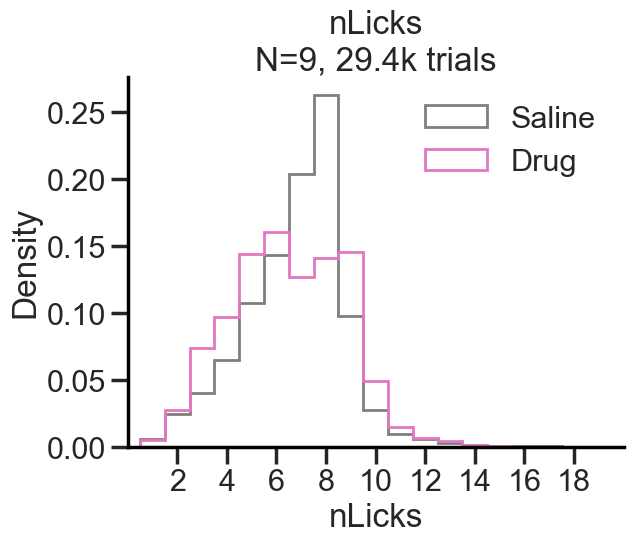

In [15]:
# Correct trials only (that's why the number of trials is half as in RT or ILI distributions)
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='drug', kind='kde')

In [16]:
# plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='nLicks', split='drug', kind='kde')

nLicks: t-statistic = 3.740, p-value = 0.006


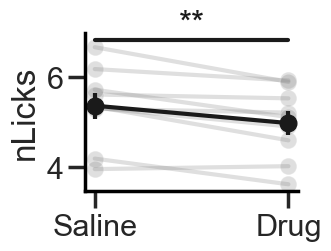

In [17]:
plot_var_drug(df_behavior, var_name='nLicks')
# plot_var_drug(df_behavior[df_behavior.Hit==0], var_name='nLicks', color='tab:red')
# plot_var_drug(df_behavior[df_behavior.Hit==1], var_name='nLicks', color='tab:green')

Text(0.5, 1.0, 'Saline')

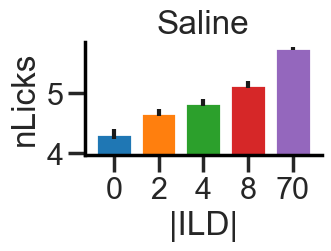

In [18]:
# Saline
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='nLicks')
plt.title('Saline')

Text(0.5, 1.0, 'Drug')

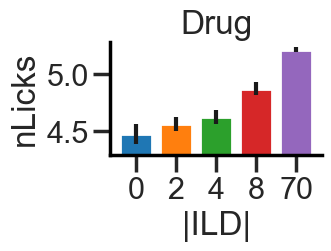

In [19]:
# Drug
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='nLicks')
plt.title('Drug')

### ILI

(0.0, 0.2)

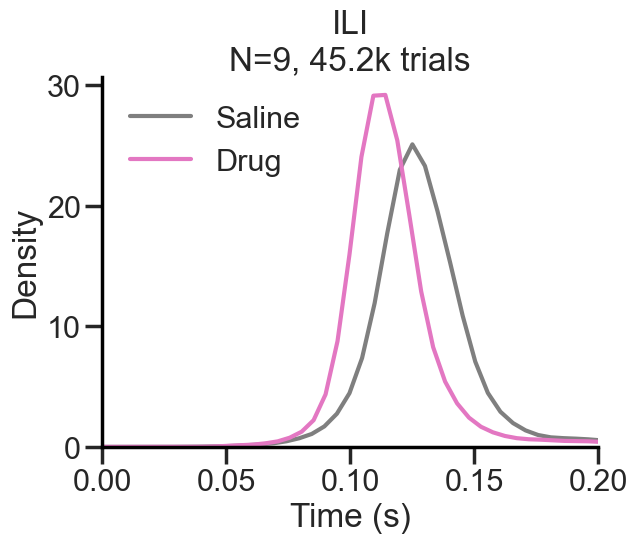

In [20]:
plot_licks_split(df_behavior, var='ILI', split='drug', kind='kde')
plt.xlim(0, 0.2)

In [21]:
# plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='ILI', split='drug', kind='kde')

ILI: t-statistic = 9.641, p-value = 0.000


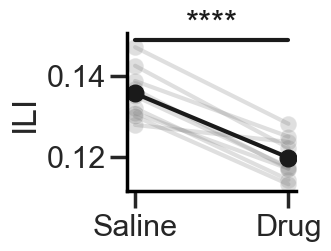

In [22]:
plot_var_drug(df_behavior, var_name='ILI')
# plot_var_drug(df_behavior[df_behavior.Hit==0], var_name='ILI', color='tab:red')
# plot_var_drug(df_behavior[df_behavior.Hit==1], var_name='ILI', color='tab:green')

Text(0.5, 1.0, 'Saline')

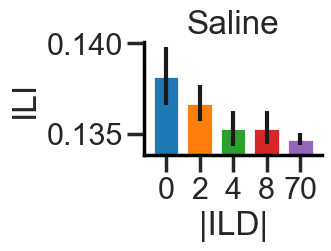

In [49]:
# Saline
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='ILI')
plt.title('Saline')

Text(0.5, 1.0, 'Drug')

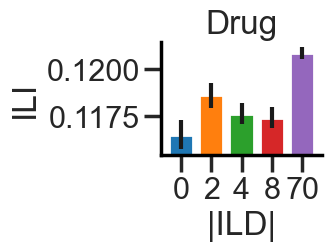

In [50]:
# Drug
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='ILI')
plt.title('Drug')

#### Mixed Effects GLM
To show that the drug removes the ILD dependence you have to show that the interaction is significant. Do a Linear Mixed model of the ILI1 with norm_trial_index, norm_trial_indx ^2, ILD, drug, drug x ILD, curren_outcome, prev_outcome, Left-Right response (binary variable to account for differences in the port side). Put session as the random effect. Do it for each mouse and plot the stats of the weights. Let’s see what comes out significant. You can use the same design matrix for the Nlicks and the z_tranformed_RT.

In [81]:
import pandas as pd
import statsmodels.formula.api as smf

subjects = df_behavior.Subject.unique()

# Prepare containers
all_fe = []
all_pvals = []

for subj in subjects:
    df_mouse = df_behavior[df_behavior.Subject == subj].copy()

    # Drop NaNs and reset index
    df_mouse = df_mouse.dropna(subset=['ILI','ILD','Drug','Hit','AfterHit','Choice'])
    df_mouse.reset_index(drop=True, inplace=True)

    df_mouse['absILD_c'] = df_mouse['absILD'] - df_mouse['absILD'].mean()

    # Add normalized trial index per session
    df_mouse['NormTrial'] = df_mouse.groupby('Session')['Trial'].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()))
    df_mouse['NormTrial2'] = df_mouse['NormTrial'] ** 2  # Squared term

    # Define formula
    formula = 'ILI ~ absILD_c + Drug + Drug:absILD_c'

    # # Updated formula
    # formula = ('ILI ~ NormTrial + NormTrial2 + ILD + Drug + '
    #            'Drug:ILD + Hit + AfterHit + Choice')

    # Fit model
    model = smf.mixedlm(formula, df_mouse, groups=df_mouse['Session'])
    result = model.fit()
    # print(result.summary())

    # Store fixed-effect estimates and p-values
    fe = result.fe_params
    fe.name = subj
    all_fe.append(fe)

    pvals = result.pvalues
    pvals.name = subj
    all_pvals.append(pvals)

# Convert to DataFrames
df_fe = pd.DataFrame(all_fe)
df_p = pd.DataFrame(all_pvals)

# print(df_fe.head())
# print(df_p.head())

C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\st

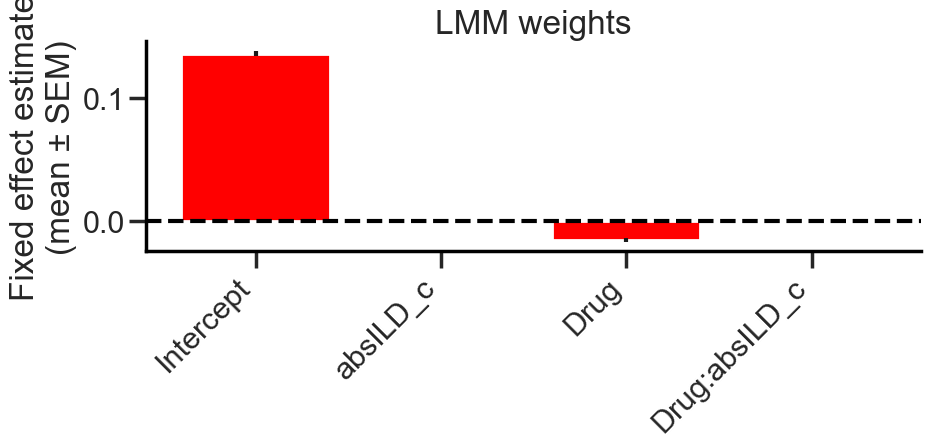

In [82]:
# Compute mean and SEM across mice
fe_mean = df_fe.mean()
fe_sem = df_fe.sem()

# Highlight effects where mean p-value < 0.05
colors = ['red' if df_p[col].mean() < 0.05 else 'gray' for col in df_fe.columns]

plt.figure(figsize=(10,5))
plt.bar(range(len(fe_mean)), fe_mean, yerr=fe_sem, color=colors)
plt.xticks(range(len(fe_mean)), fe_mean.index, rotation=45, ha='right')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Fixed effect estimate\n(mean ± SEM)')
plt.title('LMM weights')
plt.tight_layout()

# Psychometrics

In [25]:
def compare_psych_params(params, param_name):
    """
    Compare the parameters of the saline and drug conditions.
    """

    subject = np.tile(np.arange(len(params) // 2), 2)
    params['subject'] = subject
    var_mean = params.groupby('drug')[param_name].mean()
    var_sem = params.groupby('drug')[param_name].sem()

    plt.figure(figsize=default_figsize/2, constrained_layout=True)

    # # Plot boxplot
    # sns.boxplot(data=params, x='drug', y=param_name, hue='drug', palette=['tab:gray', 'tab:pink'], linewidth=2.5, showfliers=False, legend=False)
    # sns.swarmplot(data=params, x='drug', y=param_name, color='k', legend=False)

    # Plot paired lines
    sns.lineplot(data=params, x='drug', y=param_name, hue='subject', marker='o', palette=['gray'] * int(len(params)/2), alpha=0.25, legend=False)
    # Plot mean and SEM
    plt.errorbar(x=var_mean.index, y=var_mean.values, yerr=var_sem.values, fmt='-o', color='k')

    # plt.title(var_name)
    plt.ylabel(param_name)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))  # Set a global formatter for y-axis ticks for equal sized plots
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    # Add stats
    saline = params[params['drug'] == 0][param_name]
    drug = params[params['drug'] == 1][param_name]
    t_stat, p_val = ttest_rel(saline, drug)
    print(f"{param_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
    add_star_between(p_val)

## Probability choose RIGHT

In [26]:
kind = 'prob_right'

### Single animals

In [27]:
# for animal in animals:
#     print(f'Animal {animal}')
#     plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind)


### Mean across animals

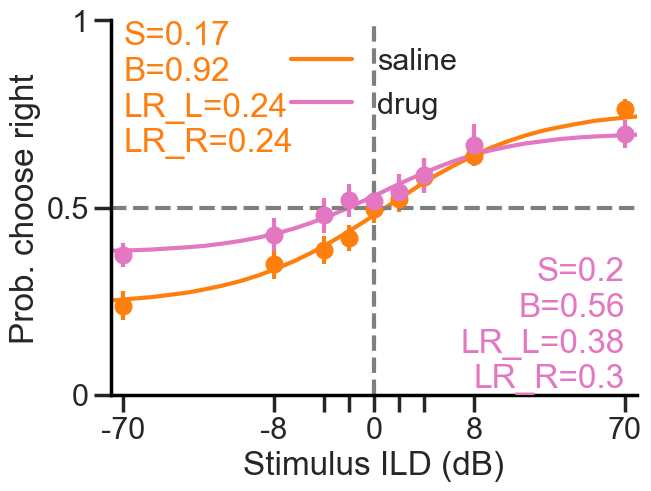

In [28]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind)

#### Stats

sensitivity: t-statistic = -1.077, p-value = 0.313
bias: t-statistic = 0.652, p-value = 0.533
lr_right: t-statistic = -2.728, p-value = 0.026
lr_left: t-statistic = -1.251, p-value = 0.246


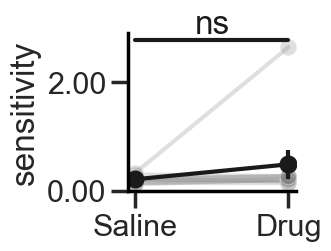

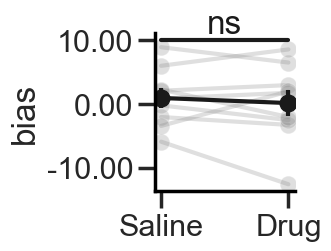

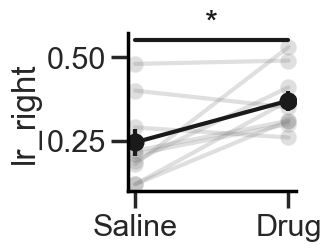

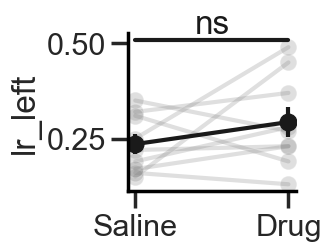

In [29]:
compare_psych_params(params, 'sensitivity')
compare_psych_params(params, 'bias')
compare_psych_params(params, 'lr_right')
compare_psych_params(params, 'lr_left')

## Probability choose REPEAT

In [30]:
kind = 'prob_rep'

### Single animals

In [31]:
# for animal in animals:
#     print(f'Animal {animal}')
#     plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind)

### Mean across animals

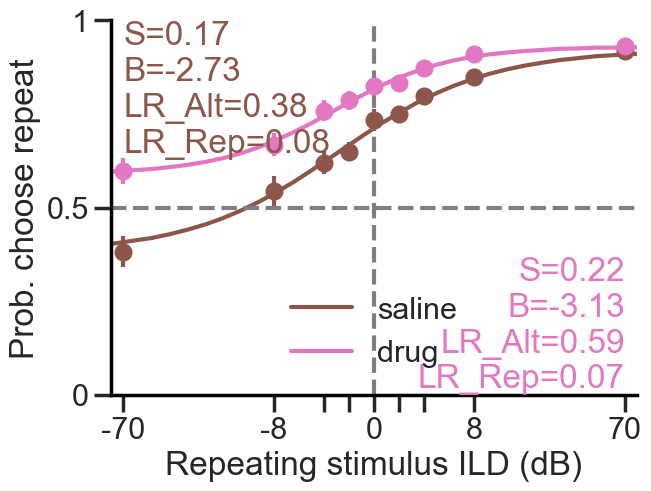

In [32]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind)

#### Stats

sensitivity: t-statistic = -2.322, p-value = 0.049
bias: t-statistic = 0.419, p-value = 0.686
lr_rep: t-statistic = -7.894, p-value = 0.000
lr_alt: t-statistic = 0.832, p-value = 0.430


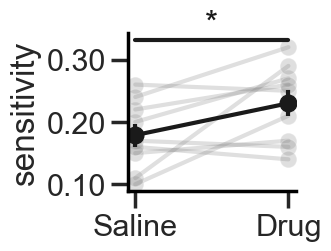

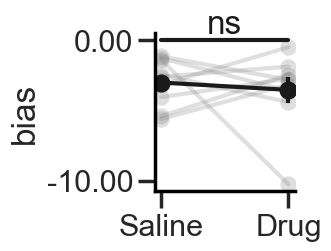

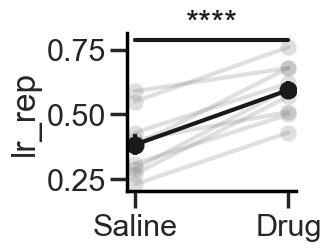

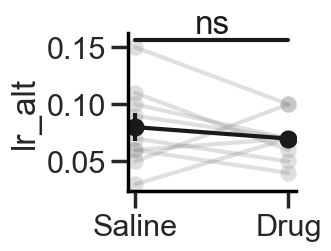

In [33]:
compare_psych_params(params, 'sensitivity')
compare_psych_params(params, 'bias')
compare_psych_params(params, 'lr_rep')
compare_psych_params(params, 'lr_alt')

# Kernels

## Psychophysical kernels

### Mean across animals

In [34]:
# Set parameters
experiment = ['2AFC_6']
animal = None

In [35]:
# Saline
# plot_pk(experiment=experiment, animal=animal, target_ilds=None, drug=0, residuals=True, zscore=False,
#             control=None, n_mean_frames=None, iterations=10, save=False)

# Drug
# plot_pk(experiment=experiment, animal=animal, target_ilds=None, drug=1, residuals=True, zscore=False,
#             control=None, n_mean_frames=None, iterations=10, save=False)

2AFC_6
C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_6
Getting kernel of animal 014 (1/11)
get_pk took 1.47 seconds to run
Getting kernel of animal 016 (2/11)
get_pk took 1.63 seconds to run
Getting kernel of animal 017 (3/11)
get_pk took 1.78 seconds to run
Getting kernel of animal 018 (4/11)
get_pk took 1.06 seconds to run
Getting kernel of animal 019 (5/11)
get_pk took 1.27 seconds to run
Getting kernel of animal 020 (6/11)
get_pk took 1.43 seconds to run
Getting kernel of animal 021 (7/11)
Could not get kernel of animal 021
zero-size array to reduction operation maximum which has no identity
Getting kernel of animal 022 (8/11)
Could not get kernel of animal 022
zero-size array to reduction operation maximum which has no identity
Getting kernel of animal 023 (9/11)
get_pk took 1.33 seconds to run
Getting kernel of animal 024 (10/11)
get_pk took 1.35 seconds to run
Getting kernel of animal 025 (11/11)
Could not get kernel of animal 025
zero-size array to reduction operation max

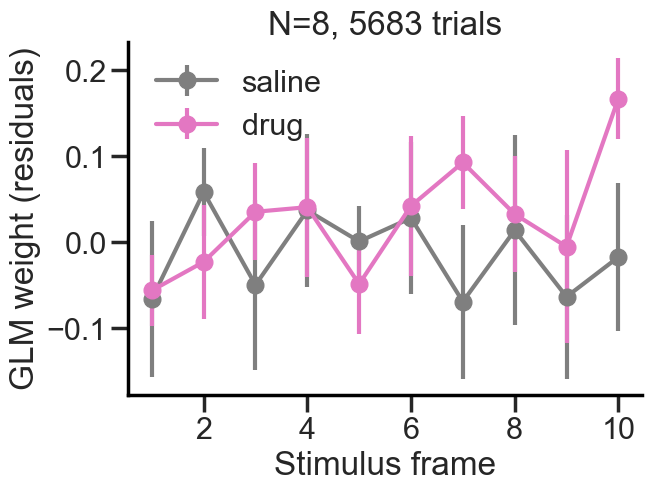

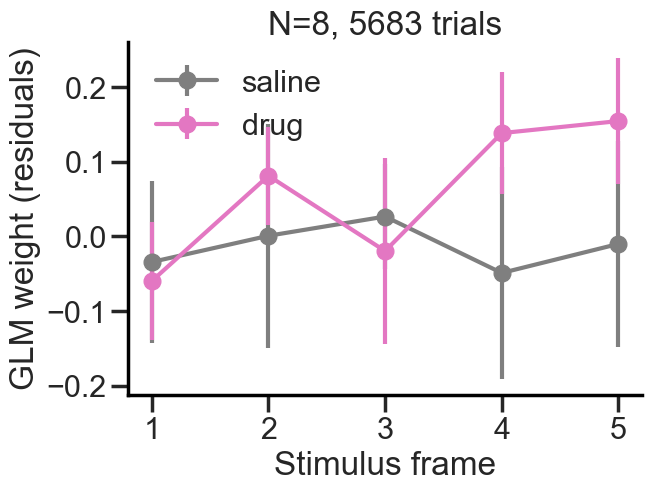

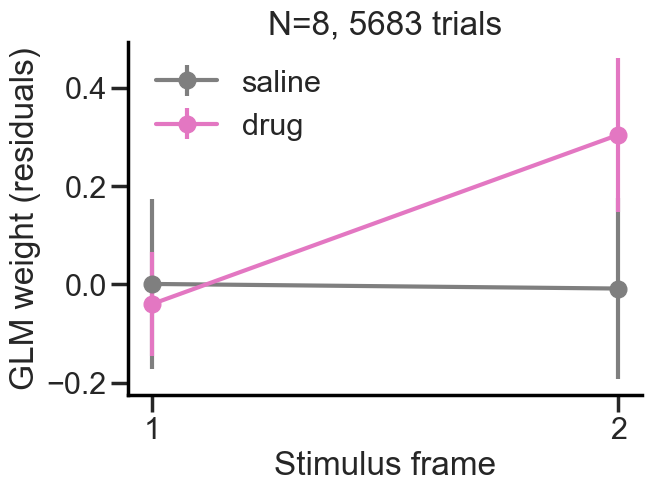

In [36]:
# All frames
plot_drug_pk(experiment=experiment, animal=None, target_ilds=None, drug=None, residuals=True, zscore=False,
            control=None, n_mean_frames=None, iterations=1, save=False)
# 5 mean frames
n_mean_frames = 5
plot_drug_pk(experiment=experiment, animal=None, target_ilds=None, drug=None, residuals=True, zscore=False,
            control=None, n_mean_frames=n_mean_frames, iterations=1, save=False)
# 2 mean frames
n_mean_frames = 2
plot_drug_pk(experiment=experiment, animal=None, target_ilds=None, drug=None, residuals=True, zscore=False,
            control=None, n_mean_frames=n_mean_frames, iterations=1, save=False)

## History kernels

# Serial dependence

Serial dependence requires a continuous readout of behavioral responses. As choices are binary (left/right), other readouts are needed. Let's try with reaction times (RT) and lick rate (nLicks)

In [37]:
df = df_behavior

loc = df.columns.get_loc('Side') + 1
df.insert(loc, 'PreviousSide', df['Side'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousSide') + 1
df.insert(loc, 'RepSide', (df['Side'] == df['PreviousSide']).astype(int))  # Add repeating stimulus column
loc = df.columns.get_loc('ILD') + 1
df.insert(loc, 'PreviousILD', df['ILD'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousILD') + 1
df.insert(loc, 'DeltaILD', df.PreviousILD - df.ILD)  # Add previous stimulus side column
loc = df.columns.get_loc('DeltaILD') + 1
df.insert(loc, 'absDeltaILD', abs(df.DeltaILD))  # Add previous stimulus side column

# Filter data
df = df[df.Task == 'FD'].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)
df = df[df.Hit == 1].reset_index(drop=True)

# loc = df.columns.get_loc('nLicksRight') + 1  # Added to add_licks function
# df.insert(loc, 'nLicks', np.where(df['Side'] == 0, df['nLicksLeft'], df['nLicksRight']))  # Add number of licks column

# Center at 0 variables of interest
df.nLicks = df.nLicks - df.nLicks.mean()  # Substract its mean to nLicks
df.RT = df.RT - df.RT.mean()  # Substract its mean to RT
df.RT2 = df.RT2 - df.RT2.mean()  # Substract its mean to RT2

df.head()

,Trial,Side,PreviousSide,RepSide,RepTrial,Reward,Punish,Miss,WrongLick,Hit,...,LicksRight,nLicksLeft,nLicksRight,nLicks,leftILI,rightILI,ILI,RT,RT2,SessionHalf
0,153,1,NaN,0,1.0,1,0,0,0,1.0,...,"[1.9182000000000001, 2.0352, 2.1423, 2.2552999...",0,8,1.339193,NaN,0.125586,0.125586,0.087397,0.087397,1
1,152,1,1.0,1,1.0,1,0,0,0,1.0,...,"[1.9499000000000004, 2.067, 2.1710000000000003...",0,8,1.339193,NaN,0.122971,0.122971,0.119097,0.119097,1
2,151,1,1.0,1,1.0,1,0,0,0,1.0,...,"[1.9076999999999997, 2.0181, 2.138699999999999...",0,4,-2.660807,NaN,0.121300,0.121300,0.076897,0.076897,1
3,150,1,1.0,1,0.0,1,0,0,0,1.0,...,"[1.9677000000000002, 2.108, 2.22, 2.3375999999...",0,6,-0.660807,NaN,0.126860,0.126860,0.136897,0.136897,1
4,146,1,1.0,1,1.0,1,0,0,0,1.0,...,"[1.943, 2.0660000000000003, 2.1828, 2.29449999...",0,7,0.339193,NaN,0.120250,0.120250,0.112197,0.112197,1


In [38]:
# Check value range of DeltaILD for binning later
np.array(sorted(df.DeltaILD.unique()))

array([  nan, -140.,  -78.,  -74.,  -72.,  -70.,  -68.,  -66.,  -62.,
        -16.,  -12.,  -10.,   -8.,   -6.,   -4.,   -2.,    0.,    2.,
          4.,    6.,    8.,   10.,   12.,   16.,   62.,   66.,   68.,
         70.,   72.,   74.,   78.,  140.])

In [39]:
def plot_binned_deltaILD(var='RT', absolute=False):
    """
    Plot binned deltaILD distribution.
    :param var: variable to plot
    :param abs: if True, plot absolute values of deltaILD
    :return:
    """

    # Set bin edges
    if absolute:
        bins = [0, 5, 10, 20, 70, 80, 140]
        col_name = 'absDeltaILD'
        xlabel = 'abs(ΔILD)'
    else:
        bins = [-140, -80, -70, -20, -10, -5 , 5, 10, 20, 70, 80, 140]
        xlabel = 'ΔILD'
        col_name = 'DeltaILD'

    # Create bin labels ( as the bin spacing is not continuous)
    labels = [f"{bins[i]}:{bins[i+1]}" for i in range(len(bins)-1)]

    # Bin the data
    df['ILDbin'] = pd.cut(df[col_name], bins=bins, labels=labels, include_lowest=True)

    # Group and compute means
    mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()

    # Plot
    plt.figure(constrained_layout=True)
    plt.bar(mean_licks['ILDbin'], mean_licks[var], color='tab:gray')
    plt.xlabel(xlabel)
    plt.ylabel(var)
    plt.xticks(rotation=45)
    plt.title(f'{var} by {xlabel}')
    sns.despine()

### Measured as Reaction Times (RTs)

RT: t-statistic = -2.968, p-value = 0.003


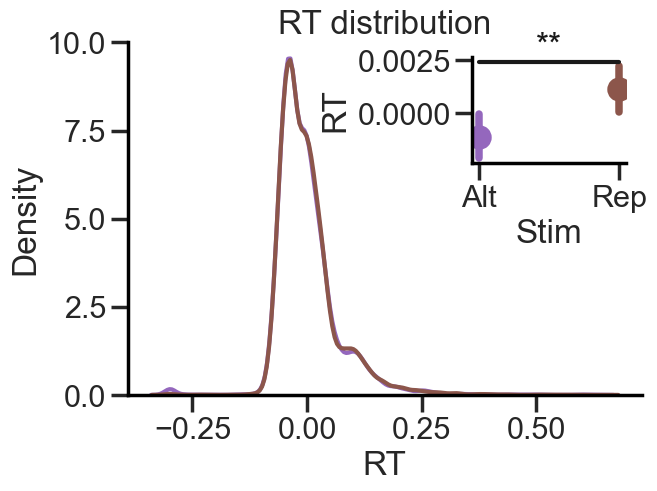

In [40]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].RT, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].RT, label='alt_stim', color='tab:brown')
plt.title('RT distribution')
# plt.legend(frameon=False)
sns.despine()

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='RT', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')

# Run t-test
var_name = 'RT'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

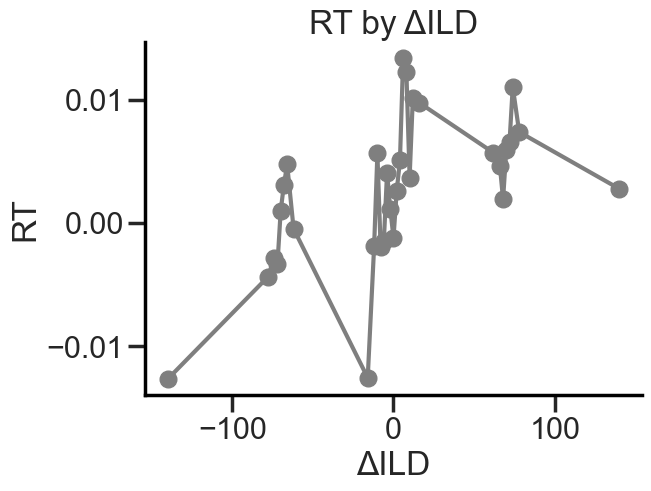

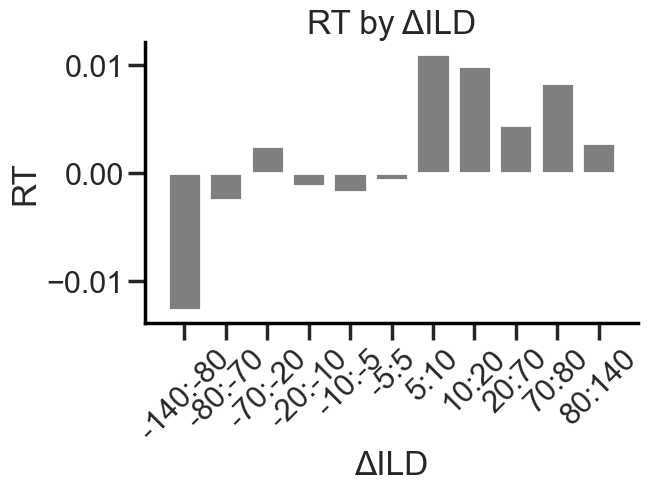

In [41]:
# Plot the RT by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('RT')
plt.title('RT by ΔILD')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=False)

##### Absolute ΔILD

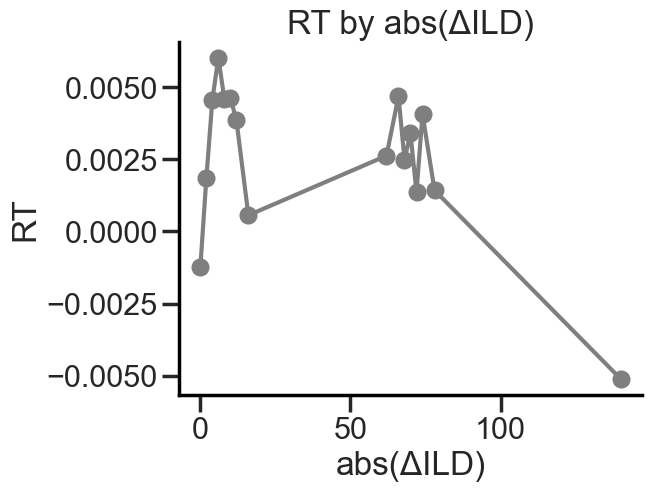

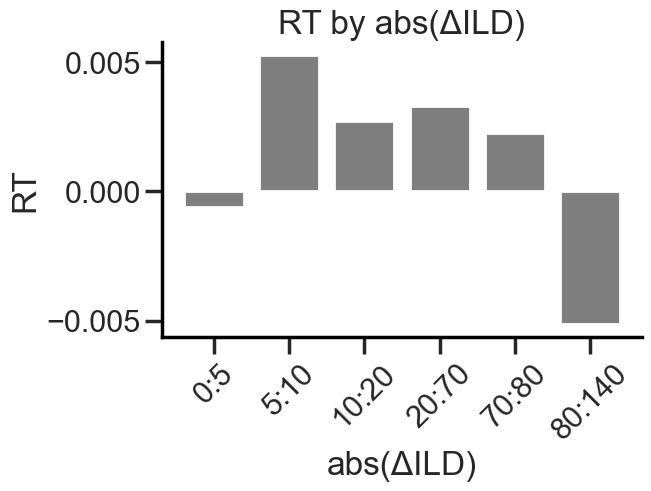

In [42]:
# Plot the RT by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('RT')
plt.title('RT by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=True)

### Measured as N licks

nLicks: t-statistic = 2.009, p-value = 0.045


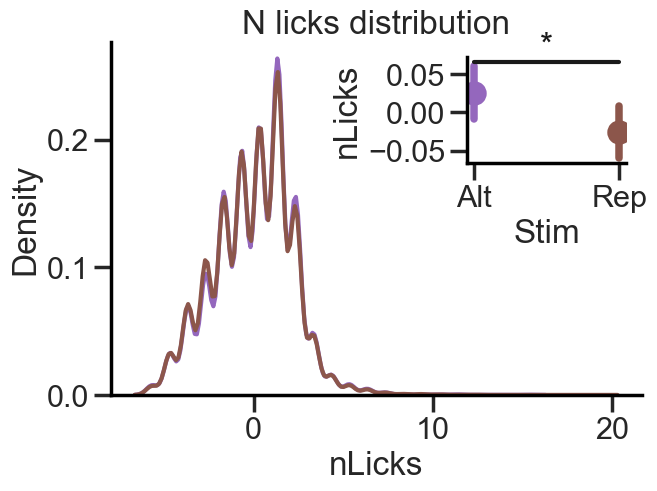

In [43]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].nLicks, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].nLicks, label='alt_stim', color='tab:brown')
plt.title('N licks distribution')
# plt.legend(frameon=False)

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='nLicks', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')
sns.despine()

# Run t-test
var_name = 'nLicks'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

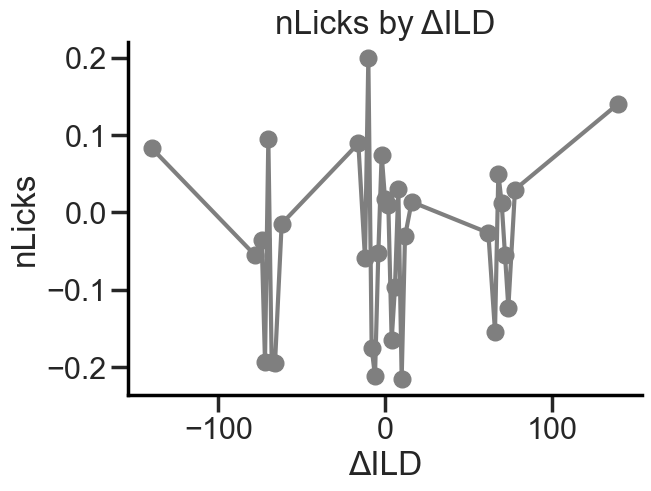

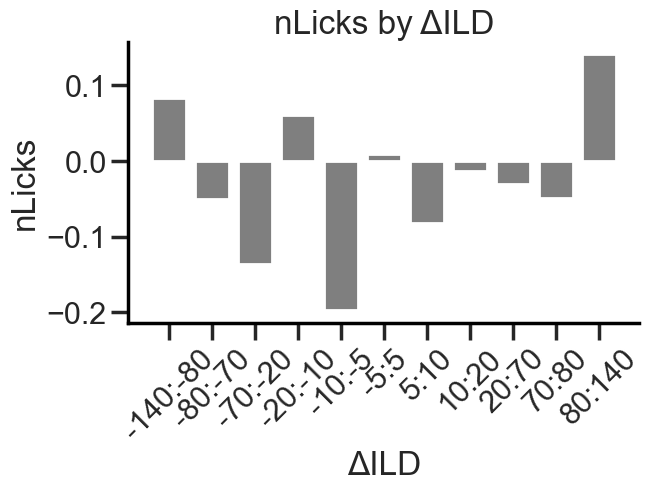

In [44]:
# Plot the number of licks by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('nLicks')
plt.title('nLicks by ΔILD')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=False)

##### Absolute ΔILD

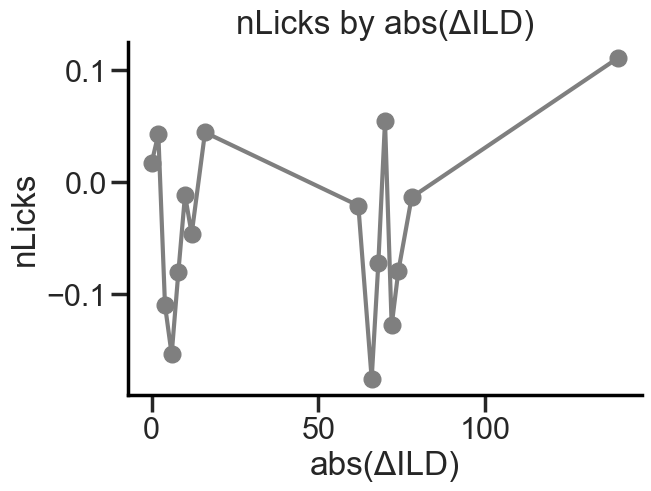

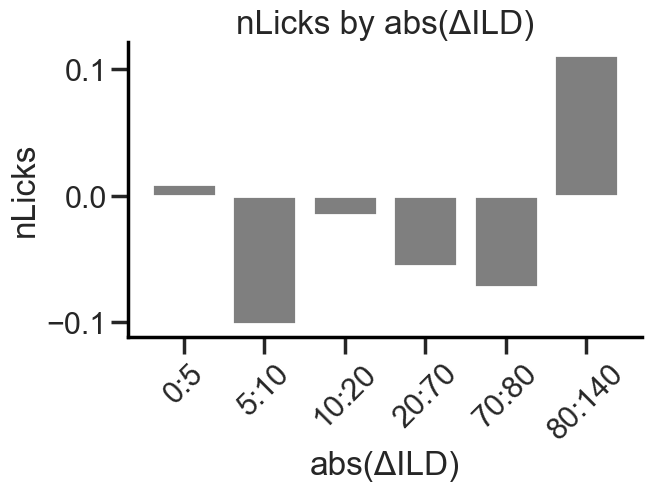

In [45]:
# Plot the number of licks by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('nLicks')
plt.title('nLicks by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=True)

# Save all notebook's figures

In [46]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# # Export all figures
# save_notebook_files("notebook.ipynb")